# 02 · Exploratory data analysis

**Questions:**
1. What do customers complain about most?
2. Which complaint types most often go the customer's way?
3. How do the big banking groups compare?
4. Do digital banks, high-street banks and car-finance lenders differ?

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make "src" importable when the notebook runs from the notebooks/ folder
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_colwidth", 120)

In [2]:
df = pd.read_csv(ROOT / "data" / "processed" / "decisions_clean.csv", parse_dates=["decision_date", "period_start"])
from src.labels import THEME_ORDER
overall_rate = df["upheld"].mean()
print(f"{len(df)} decisions | overall upheld rate: {overall_rate:.1%}")

960 decisions | overall upheld rate: 26.9%


## 1. What do customers complain about?

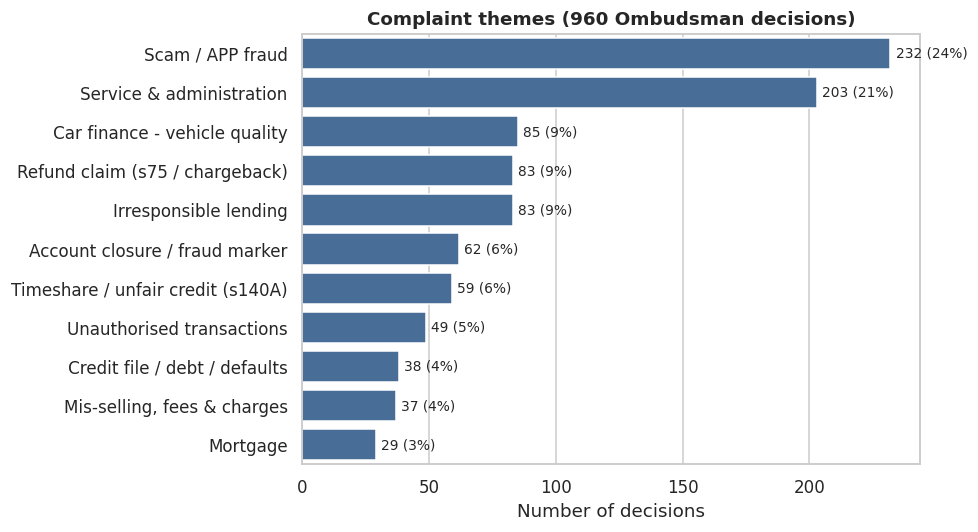

In [3]:
theme_counts = df["theme"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=theme_counts.values, y=theme_counts.index, color="#3b6ea5", ax=ax)
for i, v in enumerate(theme_counts.values):
    ax.text(v + 2, i, f"{v} ({v/len(df):.0%})", va="center", fontsize=9)
ax.set(title="Complaint themes (960 Ombudsman decisions)", xlabel="Number of decisions", ylabel="")
plt.tight_layout(); plt.savefig(FIG_DIR / "01_theme_counts.png"); plt.show()

**Scams are the single biggest theme**, roughly a quarter of all decisions. Most are authorised push payment (APP) scams: investment, job, romance and impersonation scams.

## 2. Which complaints win?
The upheld rate is the share of decisions where the ombudsman found in the customer's favour.
Small groups give unreliable rates, so each bar shows its sample size (n).

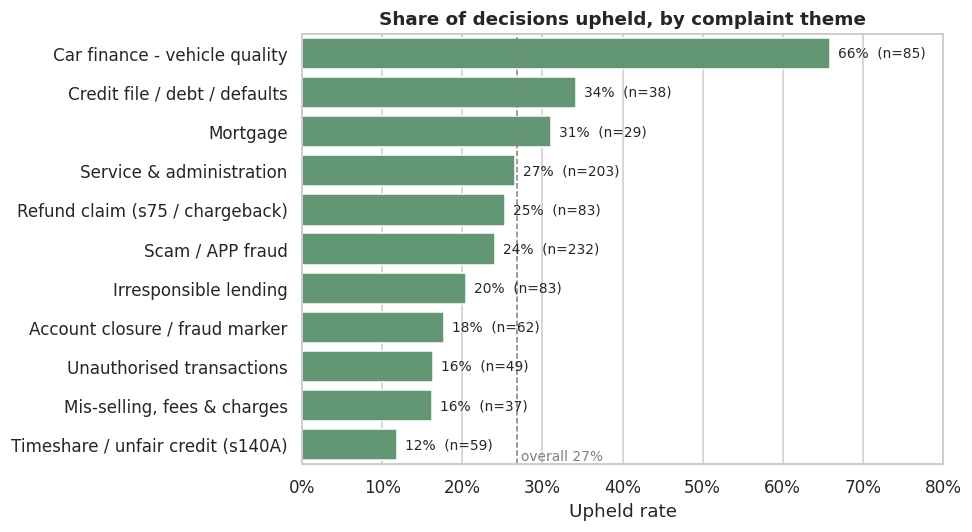

,rate,n
theme,,
Car finance - vehicle quality,65.9%,85
Credit file / debt / defaults,34.2%,38
Mortgage,31.0%,29
Service & administration,26.6%,203
Refund claim (s75 / chargeback),25.3%,83
Scam / APP fraud,24.1%,232
Irresponsible lending,20.5%,83
Account closure / fraud marker,17.7%,62
Unauthorised transactions,16.3%,49


In [4]:
theme_rate = (df.groupby("theme")["upheld"].agg(rate="mean", n="size")
              .sort_values("rate", ascending=False))
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=theme_rate["rate"], y=theme_rate.index, color="#5a9e6f", ax=ax)
ax.axvline(overall_rate, color="grey", ls="--", lw=1)
ax.text(overall_rate + 0.005, len(theme_rate) - 0.6, f"overall {overall_rate:.0%}", color="grey", fontsize=9)
for i, (r, n) in enumerate(zip(theme_rate["rate"], theme_rate["n"])):
    ax.text(r + 0.01, i, f"{r:.0%}  (n={n})", va="center", fontsize=9)
ax.set(title="Share of decisions upheld, by complaint theme", xlabel="Upheld rate", ylabel="", xlim=(0, 0.8))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout(); plt.savefig(FIG_DIR / "02_upheld_rate_by_theme.png"); plt.show()
theme_rate.style.format({"rate": "{:.1%}"})

**Car-finance vehicle quality complaints are upheld far more often than anything else**, while timeshare/s140A claims
(mostly brought by claims firms) are rarely upheld. Scam complaints sit close to the average: customers win roughly one in four.

## 3. How do the major banking groups compare?
Only groups with at least 20 decisions are shown, to avoid over-reading tiny samples.

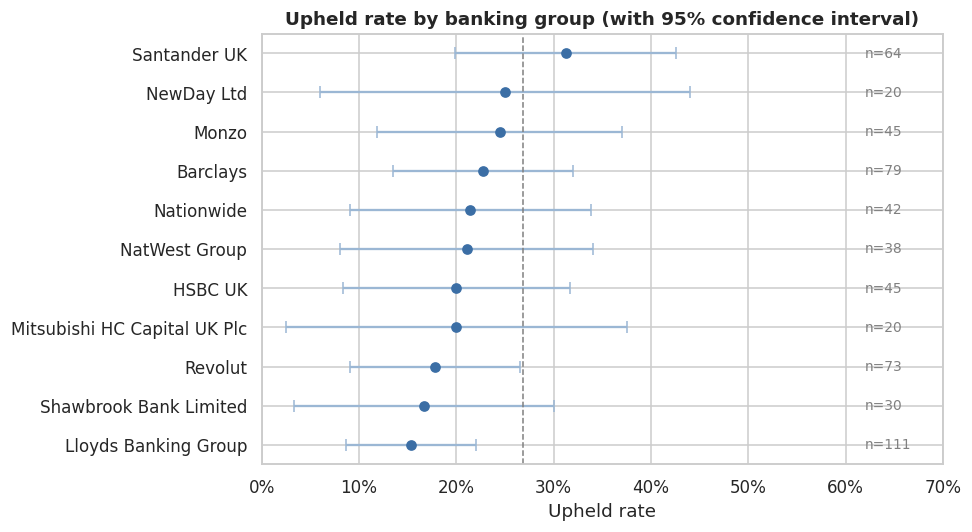

,rate,n,ci
firm_group,,,
Santander UK,31.2%,64,±11.4%
NewDay Ltd,25.0%,20,±19.0%
Monzo,24.4%,45,±12.6%
Barclays,22.8%,79,±9.2%
Nationwide,21.4%,42,±12.4%
NatWest Group,21.1%,38,±13.0%
HSBC UK,20.0%,45,±11.7%
Mitsubishi HC Capital UK Plc,20.0%,20,±17.5%
Revolut,17.8%,73,±8.8%


In [5]:
grp = (df.groupby("firm_group")["upheld"].agg(rate="mean", n="size")
         .query("n >= 20").sort_values("rate", ascending=False))

# 95% confidence interval for each rate (normal approximation)
grp["ci"] = 1.96 * np.sqrt(grp["rate"] * (1 - grp["rate"]) / grp["n"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(grp["rate"], grp.index, xerr=grp["ci"], fmt="o", color="#3b6ea5", ecolor="#9bb7d4", capsize=4)
ax.axvline(overall_rate, color="grey", ls="--", lw=1)
for i, (r, n) in enumerate(zip(grp["rate"], grp["n"])):
    ax.text(0.62, i, f"n={n}", va="center", fontsize=9, color="grey")
ax.invert_yaxis()
ax.set(title="Upheld rate by banking group (with 95% confidence interval)", xlabel="Upheld rate", xlim=(0, 0.7))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout(); plt.savefig(FIG_DIR / "03_upheld_rate_by_group.png"); plt.show()
grp.style.format({"rate": "{:.1%}", "ci": "±{:.1%}"})

**Read this carefully:** most confidence intervals overlap. With 20–110 decisions per group we can't rank the banks with confidence.
The one gap worth a closer look is **Lloyds Banking Group (lowest) vs Santander UK (highest)**, but even that may reflect a different
*mix* of complaints rather than how each bank behaves. "How confident are you?" is a common interview question; this is the honest answer.

## 4. What each type of firm gets complaints about

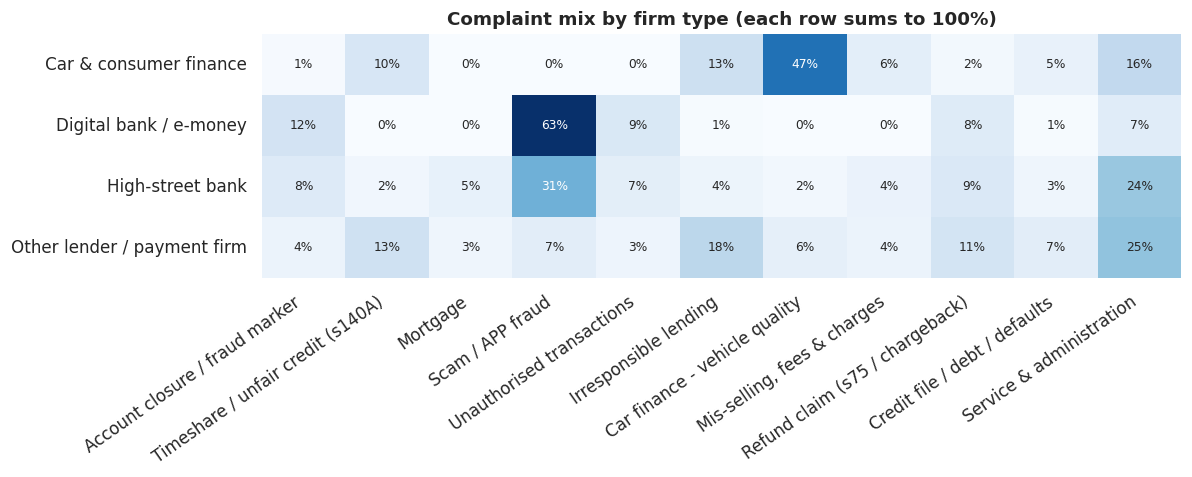

In [6]:
mix = pd.crosstab(df["firm_type"], df["theme"], normalize="index")[THEME_ORDER]
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(mix, annot=True, fmt=".0%", cmap="Blues", cbar=False, ax=ax, annot_kws={"fontsize": 8})
ax.set(title="Complaint mix by firm type (each row sums to 100%)", xlabel="", ylabel="")
plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig(FIG_DIR / "04_theme_mix_by_firm_type.png"); plt.show()

In [7]:
pd.crosstab(df["firm_type"], df["upheld"], margins=True).rename(columns={0: "not upheld", 1: "upheld"})

upheld,not upheld,upheld,All
firm_type,,,
Car & consumer finance,68,60,128
Digital bank / e-money,110,29,139
High-street bank,320,90,410
Other lender / payment firm,204,79,283
All,702,258,960


## Key findings
1. **Scams dominate**: about a quarter of banking complaints reaching the ombudsman are APP scams. For digital banks it's over half.
2. **Outcome depends mostly on the type of complaint**: vehicle quality ~60%+ upheld vs timeshare/s140A ~10%.
3. **Bank-to-bank differences are mostly within the margin of error** at this sample size; the theme of the complaint explains far more than which bank it is.
4. The **"Service & administration"** bucket is large; a next step would be to split it with better rules or the clustering in notebook 03.